# Memory Hierarchy

Develop an experiment that exposes the latency and bandwidth effects of the CPU memory hierarchy.

## Objectives

Relate working-set size and access pattern to cache and main-memory behavior.

## Background

Caches exploit temporal and spatial locality; access patterns that exceed or bypass them expose slower memory levels.

## Prediction

A dependent randomized pointer-chasing workload should show increasing access latency as its working set exceeds successive cache capacities. The first transition is expected around the private L1 data-cache capacity, another around the private L2 capacity, and a further transition near the shared L3 capacity. Because CPUs 5 and 15 belong to L3 domains of 8 MiB and 16 MiB respectively, working sets between those capacities may exhibit lower latency on CPU 15. Working sets substantially larger than both L3 caches should approach main-memory latency on both CPUs.

## Environment

In [5]:
import os
import platform
import socket
import sys
from pathlib import Path

repository_root = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "pyproject.toml").is_file()
    ),
    None,
)
if repository_root is None:
    raise RuntimeError("Run this notebook from within the repository")
if str(repository_root) not in sys.path:
    sys.path.insert(0, str(repository_root))

print(f"Python: {sys.version}")
print(f"Platform: {platform.platform()}")
print(f"Hostname: {socket.gethostname()}")
print(f"Working directory: {os.getcwd()}")

Python: 3.14.3 (main, Feb 12 2026, 00:45:04) [Clang 21.1.4 ]
Platform: Linux-6.17.0-1026-nvidia-aarch64-with-glibc2.39
Hostname: spark-0240
Working directory: /home/coert/workspace/dgx-spark-lab/experiments/00-foundations


## Experiment

In [7]:
from pathlib import Path

import pandas as pd


def read_optional(path: Path) -> str | None:
    try:
        return path.read_text().strip()
    except (FileNotFoundError, PermissionError, OSError):
        return None


def cache_entries(cpu_id: int) -> list[dict[str, object]]:
    cache_root = Path(f"/sys/devices/system/cpu/cpu{cpu_id}/cache")
    rows: list[dict[str, object]] = []

    for index_path in sorted(cache_root.glob("index*")):
        rows.append(
            {
                "cpu": cpu_id,
                "index": index_path.name,
                "level": read_optional(index_path / "level"),
                "type": read_optional(index_path / "type"),
                "size": read_optional(index_path / "size"),
                "line_size_bytes": read_optional(index_path / "coherency_line_size"),
                "ways": read_optional(index_path / "ways_of_associativity"),
                "sets": read_optional(index_path / "number_of_sets"),
                "shared_cpu_list": read_optional(index_path / "shared_cpu_list"),
            }
        )

    return rows


REPRESENTATIVE_CPUS = [5, 15]

cache_topology = pd.DataFrame(
    row for cpu_id in REPRESENTATIVE_CPUS for row in cache_entries(cpu_id)
)

for column in [
    "level",
    "line_size_bytes",
    "ways",
    "sets",
]:
    cache_topology[column] = pd.to_numeric(
        cache_topology[column],
        errors="coerce",
    ).astype("Int64")

cache_topology

,cpu,index,level,type,size,line_size_bytes,ways,sets,shared_cpu_list
0,5,index0,1,Data,64K,64,4,256,5
1,5,index1,1,Instruction,64K,64,4,256,5
2,5,index2,2,Unified,2048K,64,8,4096,5
3,5,index3,3,Unified,8192K,64,16,8192,0-9
4,15,index0,1,Data,64K,64,4,256,15
5,15,index1,1,Instruction,64K,64,4,256,15
6,15,index2,2,Unified,2048K,64,8,4096,15
7,15,index3,3,Unified,16384K,64,16,16384,10-19


In [8]:
from pathlib import Path


def cpu_metadata(cpu_id: int) -> dict[str, object]:
    root = Path(f"/sys/devices/system/cpu/cpu{cpu_id}")

    return {
        "cpu": cpu_id,
        "cluster_id": read_optional(root / "topology/cluster_id"),
        "max_frequency_khz": read_optional(root / "cpufreq/cpuinfo_max_freq"),
        "current_frequency_khz": read_optional(root / "cpufreq/scaling_cur_freq"),
    }


representative_cpu_metadata = pd.DataFrame(
    cpu_metadata(cpu_id) for cpu_id in REPRESENTATIVE_CPUS
)

representative_cpu_metadata

,cpu,cluster_id,max_frequency_khz,current_frequency_khz
0,5,56,3900000,3900000
1,15,1144,3900000,3900000


In [ ]:
import ctypes
import hashlib
import shutil
import subprocess
import textwrap
from pathlib import Path


C_SOURCE = r"""
#define _GNU_SOURCE

#include <stdint.h>
#include <stddef.h>
#include <stdlib.h>
#include <time.h>

typedef struct __attribute__((aligned(64))) {
    uint32_t next;
    unsigned char padding[60];
} Node;

_Static_assert(sizeof(Node) == 64, "Node must occupy one cache line");

static volatile uint32_t pointer_chase_sink = 0;

static uint64_t xorshift64(uint64_t *state) {
    uint64_t value = *state;
    value ^= value << 13;
    value ^= value >> 7;
    value ^= value << 17;
    *state = value;
    return value;
}

static uint64_t elapsed_ns(
    const struct timespec *start,
    const struct timespec *end
) {
    return (
        (uint64_t)(end->tv_sec - start->tv_sec) * 1000000000ULL
        + (uint64_t)(end->tv_nsec - start->tv_nsec)
    );
}

/*
 * Return nanoseconds per dependent load.
 *
 * Every node occupies one 64-byte cache line. The nodes form one randomized
 * cycle, so each loaded index determines the location of the next load.
 */
double pointer_chase(
    size_t working_set_bytes,
    uint64_t accesses,
    uint64_t seed
) {
    if (working_set_bytes < sizeof(Node) || accesses == 0) {
        return -1.0;
    }

    size_t node_count = working_set_bytes / sizeof(Node);
    size_t allocation_bytes = node_count * sizeof(Node);

    Node *nodes = aligned_alloc(64, allocation_bytes);
    uint32_t *permutation = malloc(node_count * sizeof(uint32_t));

    if (nodes == NULL || permutation == NULL) {
        free(nodes);
        free(permutation);
        return -2.0;
    }

    for (size_t index = 0; index < node_count; ++index) {
        permutation[index] = (uint32_t)index;
    }

    uint64_t random_state = seed == 0 ? 1 : seed;

    for (size_t index = node_count - 1; index > 0; --index) {
        size_t other = xorshift64(&random_state) % (index + 1);

        uint32_t temporary = permutation[index];
        permutation[index] = permutation[other];
        permutation[other] = temporary;
    }

    for (size_t index = 0; index < node_count; ++index) {
        uint32_t current = permutation[index];
        uint32_t next = permutation[(index + 1) % node_count];
        nodes[current].next = next;
    }

    uint32_t current = permutation[0];

    /*
     * Warm up one complete traversal. This faults in the pages and fills
     * whatever cache level can retain the working set.
     */
    for (size_t index = 0; index < node_count; ++index) {
        current = nodes[current].next;
    }

    struct timespec start;
    struct timespec end;

    clock_gettime(CLOCK_MONOTONIC_RAW, &start);

    for (uint64_t index = 0; index < accesses; ++index) {
        current = nodes[current].next;
    }

    clock_gettime(CLOCK_MONOTONIC_RAW, &end);

    pointer_chase_sink = current;

    uint64_t duration_ns = elapsed_ns(&start, &end);

    free(permutation);
    free(nodes);

    return (double)duration_ns / (double)accesses;
}
"""


compiler = shutil.which("cc") or shutil.which("clang") or shutil.which("gcc")

if compiler is None:
    raise RuntimeError("No C compiler found: expected cc, clang, or gcc")

source_hash = hashlib.sha256(C_SOURCE.encode()).hexdigest()[:12]
build_directory = Path("/tmp/dgx-spark-lab-memory-hierarchy")
build_directory.mkdir(parents=True, exist_ok=True)

source_path = build_directory / f"pointer_chase_{source_hash}.c"
library_path = build_directory / f"pointer_chase_{source_hash}.so"

source_path.write_text(textwrap.dedent(C_SOURCE))

compile_result = subprocess.run(
    [
        compiler,
        "-O3",
        "-std=c11",
        "-shared",
        "-fPIC",
        "-Wall",
        "-Wextra",
        str(source_path),
        "-o",
        str(library_path),
    ],
    capture_output=True,
    text=True,
    check=False,
)

if compile_result.returncode != 0:
    raise RuntimeError(f"Pointer-chase compilation failed:\n{compile_result.stderr}")

print(f"Compiler: {compiler}")
print(f"Library: {library_path}")

Compiler: /usr/bin/cc
Library: /tmp/dgx-spark-lab-memory-hierarchy/pointer_chase_8caa2934ac70.so


In [ ]:
pointer_chase_library = ctypes.CDLL(str(library_path))

pointer_chase_native = pointer_chase_library.pointer_chase
pointer_chase_native.argtypes = [
    ctypes.c_size_t,
    ctypes.c_uint64,
    ctypes.c_uint64,
]
pointer_chase_native.restype = ctypes.c_double


def measure_pointer_chase(
    working_set_bytes: int,
    accesses: int,
    seed: int,
) -> float:
    """Return nanoseconds per dependent cache-line load."""
    result = pointer_chase_native(
        working_set_bytes,
        accesses,
        seed,
    )

    if result < 0:
        raise RuntimeError(f"Native pointer chase failed with result {result}")

    return float(result)

In [3]:
from collections.abc import Iterator
from contextlib import contextmanager


@contextmanager
def pinned_to_cpu(cpu_id: int) -> Iterator[None]:
    """Temporarily restrict the notebook kernel to one logical CPU."""
    original_affinity = os.sched_getaffinity(0)

    if cpu_id not in original_affinity:
        raise ValueError(
            f"CPU {cpu_id} is unavailable; current affinity is "
            f"{sorted(original_affinity)}"
        )

    try:
        os.sched_setaffinity(0, {cpu_id})

        if os.sched_getaffinity(0) != {cpu_id}:
            raise RuntimeError(f"Could not pin process to CPU {cpu_id}")

        yield
    finally:
        os.sched_setaffinity(0, original_affinity)

In [16]:
SANITY_SIZES = {
    "L1-sized": 32 * 1024,
    "L2-sized": 1 * 1024 * 1024,
    "L3-sized": 4 * 1024 * 1024,
    "DRAM-sized": 64 * 1024 * 1024,
}

SANITY_ACCESSES = 5_000_000

sanity_rows = []

with pinned_to_cpu(5):
    for label, size_bytes in SANITY_SIZES.items():
        latency_ns = measure_pointer_chase(
            working_set_bytes=size_bytes,
            accesses=SANITY_ACCESSES,
            seed=20260729,
        )

        sanity_rows.append(
            {
                "label": label,
                "working_set_kib": size_bytes / 1024,
                "latency_ns": latency_ns,
            }
        )

sanity_results = pd.DataFrame(sanity_rows)
sanity_results

,label,working_set_kib,latency_ns
0,L1-sized,32.0,1.286832
1,L2-sized,1024.0,4.119661
2,L3-sized,4096.0,6.201005
3,DRAM-sized,65536.0,65.198858


In [17]:
KIB = 1024
MIB = 1024 * KIB

WORKING_SET_SIZES = [
    4 * KIB,
    8 * KIB,
    16 * KIB,
    24 * KIB,
    32 * KIB,
    48 * KIB,
    64 * KIB,
    96 * KIB,
    128 * KIB,
    192 * KIB,
    256 * KIB,
    384 * KIB,
    512 * KIB,
    768 * KIB,
    1 * MIB,
    1536 * KIB,
    2 * MIB,
    3 * MIB,
    4 * MIB,
    6 * MIB,
    8 * MIB,
    10 * MIB,
    12 * MIB,
    16 * MIB,
    20 * MIB,
    24 * MIB,
    32 * MIB,
    48 * MIB,
    64 * MIB,
    96 * MIB,
    128 * MIB,
]

assert all(size % 64 == 0 for size in WORKING_SET_SIZES)
assert WORKING_SET_SIZES == sorted(set(WORKING_SET_SIZES))

len(WORKING_SET_SIZES)

31

In [ ]:
import random
import statistics
import time


REPRESENTATIVE_CPUS = {
    5: {
        "cluster_id": 56,
        "l3_mib": 8,
    },
    15: {
        "cluster_id": 1144,
        "l3_mib": 16,
    },
}

MEASUREMENT_REPETITIONS = 5
ACCESSES_PER_MEASUREMENT = 5_000_000
BASE_SEED = 20260729

measurement_plan = [
    (cpu_id, working_set_bytes, repetition)
    for cpu_id in REPRESENTATIVE_CPUS
    for working_set_bytes in WORKING_SET_SIZES
    for repetition in range(MEASUREMENT_REPETITIONS)
]

# Avoid correlating measurement order with working-set size or CPU.
random.Random(BASE_SEED).shuffle(measurement_plan)

latency_rows = []
experiment_start = time.perf_counter()

for measurement_number, (
    cpu_id,
    working_set_bytes,
    repetition,
) in enumerate(measurement_plan, start=1):
    seed = BASE_SEED + cpu_id * 1_000_003 + working_set_bytes + repetition

    with pinned_to_cpu(cpu_id):
        latency_ns = measure_pointer_chase(
            working_set_bytes=working_set_bytes,
            accesses=ACCESSES_PER_MEASUREMENT,
            seed=seed,
        )

    latency_rows.append(
        {
            "cpu": cpu_id,
            "cluster_id": REPRESENTATIVE_CPUS[cpu_id]["cluster_id"],
            "l3_mib": REPRESENTATIVE_CPUS[cpu_id]["l3_mib"],
            "working_set_bytes": working_set_bytes,
            "working_set_kib": working_set_bytes / KIB,
            "working_set_mib": working_set_bytes / MIB,
            "repetition": repetition,
            "latency_ns": latency_ns,
        }
    )

    if measurement_number % 25 == 0:
        elapsed = time.perf_counter() - experiment_start
        print(
            f"{measurement_number}/{len(measurement_plan)} "
            f"measurements completed in {elapsed:.1f} s"
        )

latency_measurements = pd.DataFrame(latency_rows)

print(
    f"Completed {len(latency_measurements)} measurements in "
    f"{time.perf_counter() - experiment_start:.1f} s"
)

latency_measurements.head()

25/310 measurements completed in 1.2 s
50/310 measurements completed in 4.9 s
75/310 measurements completed in 8.6 s
100/310 measurements completed in 9.8 s
125/310 measurements completed in 11.4 s
150/310 measurements completed in 14.5 s
175/310 measurements completed in 15.3 s
200/310 measurements completed in 17.2 s
225/310 measurements completed in 18.4 s
250/310 measurements completed in 23.3 s
275/310 measurements completed in 25.7 s
300/310 measurements completed in 27.9 s
Completed 310 measurements in 29.4 s


,cpu,cluster_id,l3_mib,working_set_bytes,working_set_kib,working_set_mib,repetition,latency_ns
0,15,1144,16,50331648,49152.0,48.000000,0,40.049616
1,5,56,8,4096,4.0,0.003906,0,1.292096
2,5,56,8,16777216,16384.0,16.000000,4,5.137658
3,5,56,8,3145728,3072.0,3.000000,2,6.065126
4,15,1144,16,98304,96.0,0.093750,1,1.404560


In [20]:
latency_summary = (
    latency_measurements.groupby(
        [
            "cpu",
            "cluster_id",
            "l3_mib",
            "working_set_bytes",
            "working_set_kib",
            "working_set_mib",
        ],
        as_index=False,
    )
    .agg(
        minimum_ns=("latency_ns", "min"),
        median_ns=("latency_ns", "median"),
        mean_ns=("latency_ns", "mean"),
        maximum_ns=("latency_ns", "max"),
        standard_deviation_ns=("latency_ns", "std"),
    )
    .sort_values(["cpu", "working_set_bytes"])
    .reset_index(drop=True)
)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
    display(latency_summary)

,cpu,cluster_id,l3_mib,working_set_bytes,working_set_kib,working_set_mib,minimum_ns,median_ns,mean_ns,maximum_ns,standard_deviation_ns
0,5,56,8,4096,4.0,0.003906,1.283424,1.285635,1.288321,1.296304,0.005626
1,5,56,8,8192,8.0,0.007812,1.286256,1.287165,1.292910,1.316832,0.013382
2,5,56,8,16384,16.0,0.015625,1.283706,1.286275,1.285972,1.288323,0.001932
3,5,56,8,24576,24.0,0.023438,1.283347,1.284797,1.284991,1.287139,0.001373
4,5,56,8,32768,32.0,0.031250,1.284816,1.286650,1.286701,1.288173,0.001470
5,5,56,8,49152,48.0,0.046875,1.283731,1.284349,1.284771,1.286464,0.001187
6,5,56,8,65536,64.0,0.062500,1.284144,1.288310,1.287592,1.289526,0.002203
7,5,56,8,98304,96.0,0.093750,1.382877,1.388682,1.394498,1.424582,0.017141
8,5,56,8,131072,128.0,0.125000,1.413283,1.420778,1.419945,1.430493,0.006924
9,5,56,8,196608,192.0,0.187500,1.491379,1.500867,1.500155,1.506531,0.005727


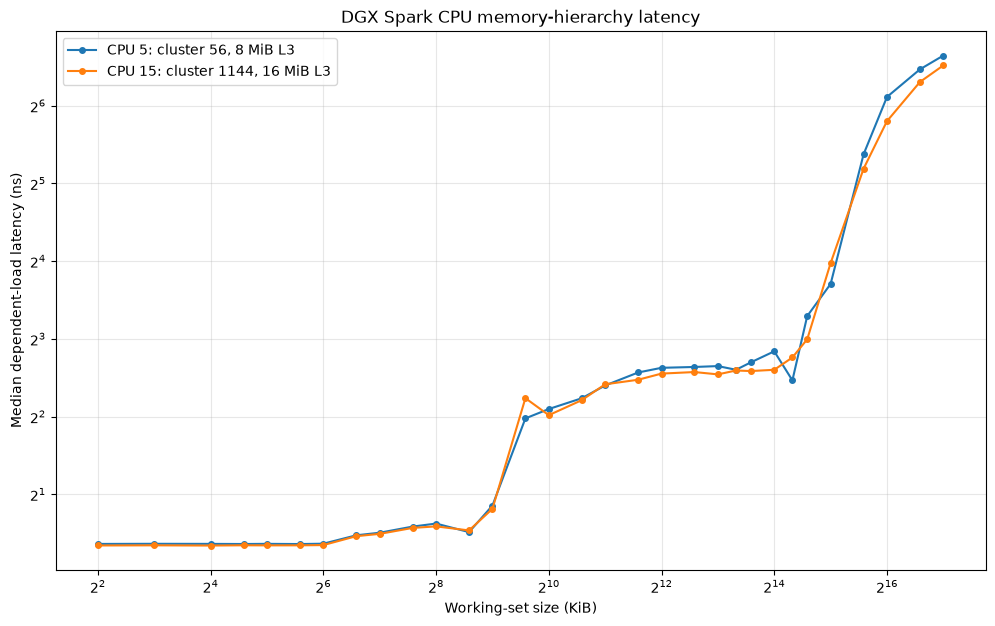

In [21]:
import matplotlib.pyplot as plt


figure, axis = plt.subplots(figsize=(12, 7))

for cpu_id, cpu_results in latency_summary.groupby("cpu"):
    metadata = REPRESENTATIVE_CPUS[int(cpu_id)]

    axis.plot(
        cpu_results["working_set_kib"],
        cpu_results["median_ns"],
        marker="o",
        markersize=4,
        label=(
            f"CPU {cpu_id}: cluster {metadata['cluster_id']}, "
            f"{metadata['l3_mib']} MiB L3"
        ),
    )

axis.set_xscale("log", base=2)
axis.set_yscale("log", base=2)

axis.set_xlabel("Working-set size (KiB)")
axis.set_ylabel("Median dependent-load latency (ns)")
axis.set_title("DGX Spark CPU memory-hierarchy latency")
axis.grid(True, which="both", alpha=0.3)
axis.legend()

plt.show()

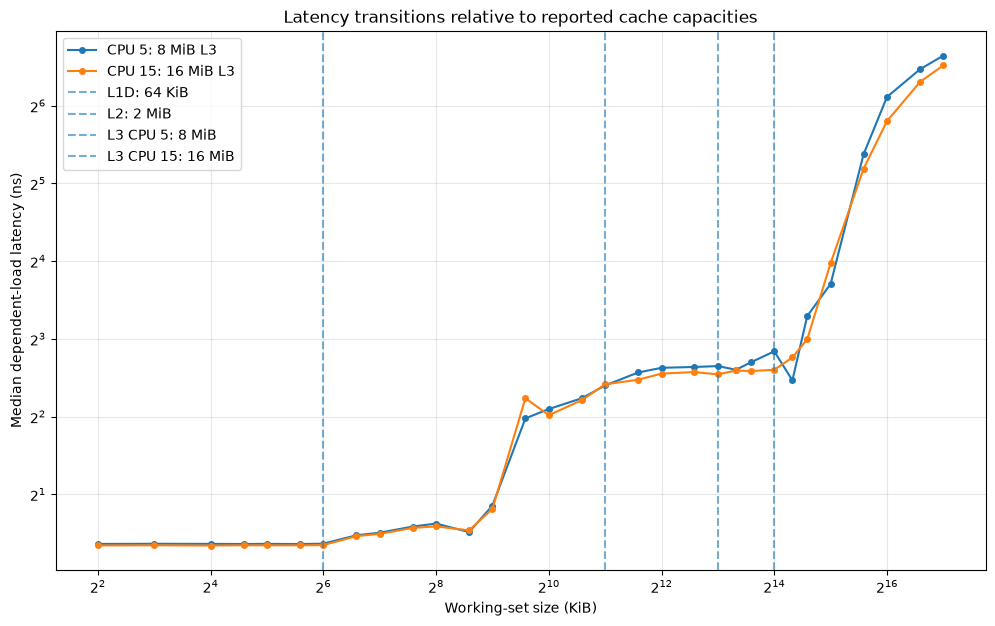

In [ ]:
figure, axis = plt.subplots(figsize=(12, 7))

for cpu_id, cpu_results in latency_summary.groupby("cpu"):
    metadata = REPRESENTATIVE_CPUS[int(cpu_id)]

    axis.plot(
        cpu_results["working_set_kib"],
        cpu_results["median_ns"],
        marker="o",
        markersize=4,
        label=(f"CPU {cpu_id}: {metadata['l3_mib']} MiB L3"),
    )

cache_boundaries_kib = {
    "L1D: 64 KiB": 64,
    "L2: 2 MiB": 2 * 1024,
    "L3 CPU 5: 8 MiB": 8 * 1024,
    "L3 CPU 15: 16 MiB": 16 * 1024,
}

for label, boundary_kib in cache_boundaries_kib.items():
    axis.axvline(
        boundary_kib,
        linestyle="--",
        alpha=0.6,
        label=label,
    )

axis.set_xscale("log", base=2)
axis.set_yscale("log", base=2)

axis.set_xlabel("Working-set size (KiB)")
axis.set_ylabel("Median dependent-load latency (ns)")
axis.set_title("Latency transitions relative to reported cache capacities")
axis.grid(True, which="both", alpha=0.3)
axis.legend()

plt.show()

In [ ]:
cluster_comparison = latency_summary.pivot(
    index=[
        "working_set_bytes",
        "working_set_kib",
        "working_set_mib",
    ],
    columns="cpu",
    values="median_ns",
).reset_index()

cluster_comparison = cluster_comparison.rename(
    columns={
        5: "cpu_5_latency_ns",
        15: "cpu_15_latency_ns",
    }
)

cluster_comparison["cpu_5_over_cpu_15"] = (
    cluster_comparison["cpu_5_latency_ns"] / cluster_comparison["cpu_15_latency_ns"]
)

cluster_comparison["cpu_15_percent_lower_latency"] = (
    1
    - (cluster_comparison["cpu_15_latency_ns"] / cluster_comparison["cpu_5_latency_ns"])
) * 100

cluster_comparison

cpu,working_set_bytes,working_set_kib,working_set_mib,cpu_5_latency_ns,cpu_15_latency_ns,cpu_5_over_cpu_15,cpu_15_percent_lower_latency
0,4096,4.0,0.003906,1.285635,1.268112,1.013818,1.362999
1,8192,8.0,0.007812,1.287165,1.269776,1.013694,1.350938
2,16384,16.0,0.015625,1.286275,1.267248,1.015015,1.479248
3,24576,24.0,0.023438,1.284797,1.270202,1.011490,1.135993
4,32768,32.0,0.031250,1.286650,1.269213,1.013738,1.355210
5,49152,48.0,0.046875,1.284349,1.269715,1.011525,1.139379
6,65536,64.0,0.062500,1.288310,1.272470,1.012448,1.229517
7,98304,96.0,0.093750,1.388682,1.377859,1.007855,0.779329
8,131072,128.0,0.125000,1.420778,1.406349,1.010260,1.015557
9,196608,192.0,0.187500,1.500867,1.483078,1.011995,1.185235


In [ ]:
cluster_comparison.query("8 <= working_set_mib <= 20")

cpu,working_set_bytes,working_set_kib,working_set_mib,cpu_5_latency_ns,cpu_15_latency_ns,cpu_5_over_cpu_15,cpu_15_percent_lower_latency
20,8388608,8192.0,8.0,6.279635,5.831696,1.076811,7.133204
21,10485760,10240.0,10.0,6.076314,6.038067,1.006334,0.629434
22,12582912,12288.0,12.0,6.492851,6.007424,1.080805,7.476333
23,16777216,16384.0,16.0,7.163357,6.075264,1.179102,15.189705
24,20971520,20480.0,20.0,5.529027,6.780666,0.815411,-22.637588


## Observations

TODO: Record measured timing distributions and working-set sizes.

## Explanation

TODO: Relate measured transitions to cache capacity, locality, and memory bandwidth.

## Connection to LLMs

Memory hierarchy behavior influences embedding lookup, preprocessing, CPU kernels, and movement of model data.

## Further Exploration

TODO: Vary stride, working-set size, and thread placement independently.